# Reconstruction of SIR dynamics via SIR-INN

We assess the epidemiological plausibility of the SIR-INN by investigating the approximation and generalization capabilities of the network, comparing the reconstructed latent dynamics with the corresponding observed quantities, in terms of S,I,R, and incidence components in the training set.

We include a verification of the SIR constancy of total population size, and an out-of-distribution analysis. 

## 1. Setup and environment

We load the required libraries and project modules.
The repository root is added to the Python path to enable local imports.

In [1]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().resolve().parent
sys.path.append(str(repo_root))

# Standard
import torch
from torch import nn
import numpy as np

# Project modules
# Neural Network loader 
from src.models.sir_inn import NN
# Evaluation and data utils
from src.evaluation.approximation import plot_sir_inn_learning, sample_scenarios_by_R0, plot_sir_conservation, compute_conservation_error, sirinn_error_grid, sirinn_error_heatmap
from src.data.data_loader import load_train_data

## 2. Load the pre-trained SIR-INN model and the data 

We firstly load the dataset used for the training and the PINN.

In [2]:
# This returns a torch tensor with the relevant features only
x_train, y_train, idx_train = load_train_data("../data/SIR-INN_dataset.csv")

# Convert tensors to numpy arrays for plotting
x_train_np = x_train.detach().numpy()
y_train_np = y_train.detach().numpy()

# Load pretrained SIR-INN model
# The model approximates the continuous-time SIR dynamics
activation = nn.Tanh
dimensions = [3, 16, 32, 16, 3]
sir_inn = NN(activation=activation, dimensions=dimensions)
sir_inn.load_state_dict(torch.load("../checkpoints/SIR-INN_pretrained.pth", map_location='cpu'))

sir_inn.eval()

NN(
  (stack): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

## 3. Qualitative reconstruction of SIR dynamics

A subset of epidemic scenarios is randomly sampled from the training set to provide representative qualitative examples.

The type of visualization is controlled via a configuration flag, allowing inspection of different aspects of the learned dynamics. Specifically, the model outputs can be viasualized under different representations:

- the full SIR compartmental dynamics,
- the infectious compartment only,
- the inferred ILI incidence, computed from the susceptible trajectory.

This analysis is purely qualitative and aims to verify that the learned dynamics are consistent with expected epidemiological behaviour, rather than
to provide a quantitative evaluation.

In [3]:
# Reconstruct SIR dynamics from the pretrained SIR-INN
# The model outputs continuous-time approximations of S(t), I(t), R(t)

with torch.no_grad():
    sir_pred = sir_inn(x_train).detach().numpy()

S_pred = sir_pred[:, 0]
I_pred = sir_pred[:, 1]
R_pred = sir_pred[:, 2]

# Observed SIR components (used for qualitative comparison)
S_obs = y_train_np[:, 0]
I_obs = y_train_np[:, 1]
R_obs = y_train_np[:, 2]

In [4]:
# Selection of representative epidemic scenarios
idx_plot = sample_scenarios_by_R0(
    x_train_np, idx_train, n_samples=12
)

In [12]:
# Flag to choose between plotting all compartments, the infectious compartment, and the infectious incidence
plot_type = 'SIR'  # choose 'SIR', 'I', or 'incidence'

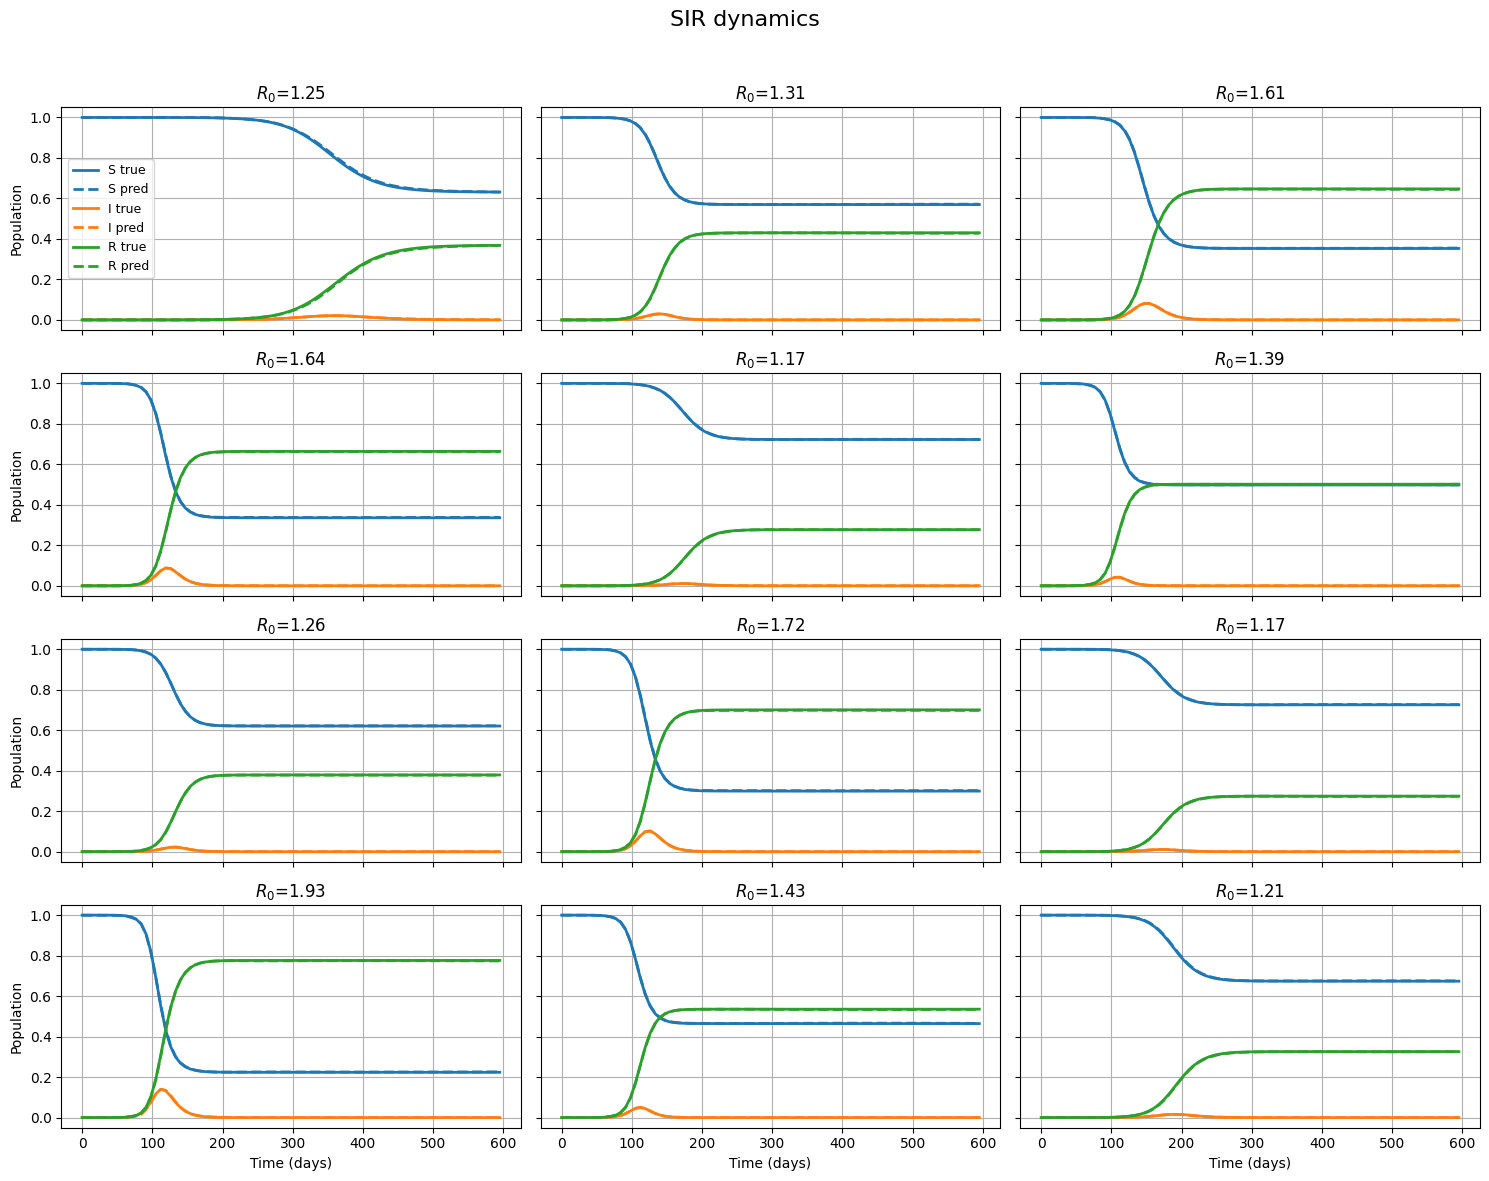

In [13]:
fig1 = plot_sir_inn_learning(
    x_train_np=x_train_np,
    idx_train=idx_train,
    idx_plot=idx_plot,
    S_obs=S_obs,
    I_obs=I_obs,
    R_obs=R_obs,
    S_pred=S_pred,
    I_pred=I_pred,
    R_pred=R_pred,
    plot_type=plot_type
)

fig1.savefig(f'../tmp_results/Plot/approximation/{plot_type}_components_approximation.png', dpi=300, bbox_inches='tight')

## 4. Population conservation check
A subset of epidemic scenarios is randomly sampled from the training set to verify that the PINN respects the conservation law: $S+I+R \approx N$ 
throughout the entire time domain. For each selected scenario, the sum of the predicted compartments is plotted against the reference value $N=1$, with per-scenario MAE and maximum absolute error reported in the panel title. 

Conservation error statistics are then computed systematically across the full training set, aggregating per-scenario metrics into a summary DataFrame and printing global MAE, maximum error, and standard deviation.

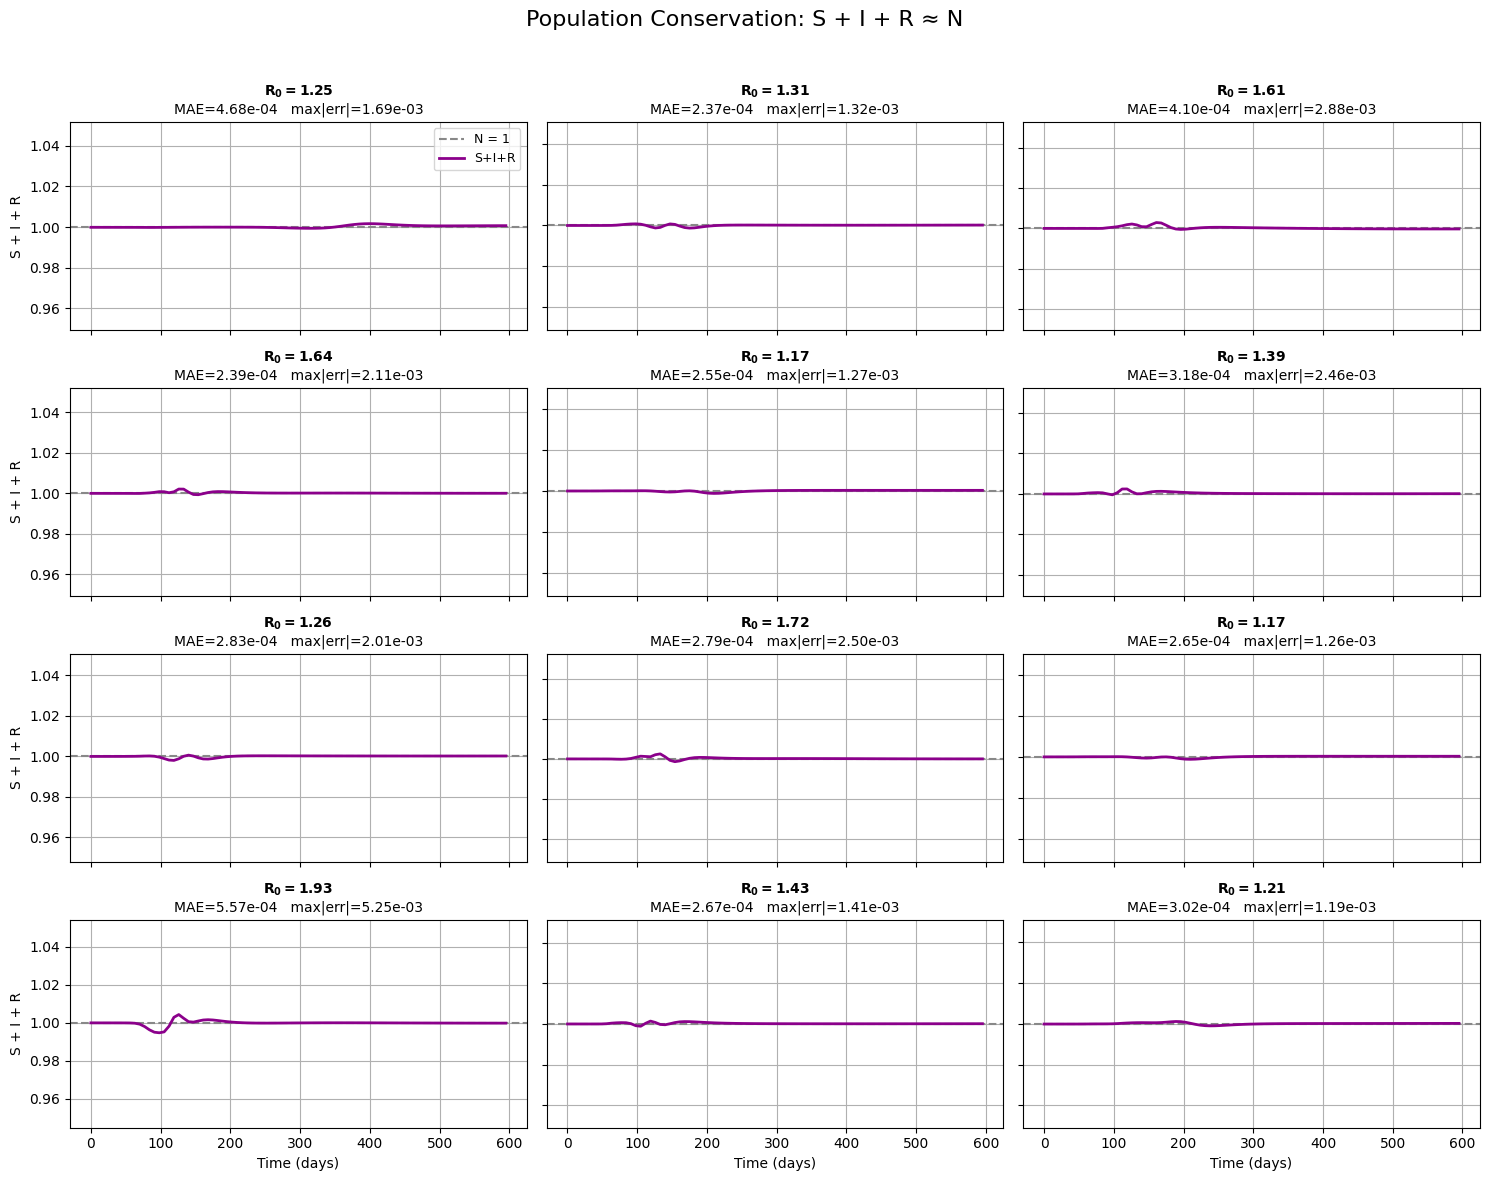

In [16]:
fig2 = plot_sir_conservation(
    x_train_np=x_train_np,
    idx_train=idx_train,
    idx_plot=idx_plot,
    S_pred=S_pred,
    I_pred=I_pred,
    R_pred=R_pred
)

fig2.savefig(f'../tmp_results/Plot/approximation/Conservation_law.png', dpi=300, bbox_inches='tight')

In [17]:
conservation_errors = compute_conservation_error(idx_train, S_pred, I_pred, R_pred)

print(conservation_errors.describe())

  Conservation Error — Full Training Set
  Global MAE     : 2.3991e-04
  Global max|err|: 2.0211e-02
  Global std     : 4.3496e-04
  # scenarios    : 1068
  # total points : 91848
               MAE      max_err      std_err
count  1068.000000  1068.000000  1068.000000
mean      0.000240     0.001351     0.000292
std       0.000184     0.001381     0.000265
min       0.000027     0.000102     0.000022
25%       0.000055     0.000141     0.000038
50%       0.000248     0.001157     0.000278
75%       0.000305     0.001976     0.000422
max       0.001373     0.020211     0.003549


## 5. Out of distribution behavior

We investigate the ability of SIR-INN in approximating the SIR model, both for training pairs of parameters ($\beta$,$\gamma$), generalizing to pairs inside the training domain boundaries, to out-of-distribution conditions (e.g., $R_0= <<1$, and $R_0>>1$).   

The metric used is the MSE between the network prediction and the exact SIR values for a given parameter pair. More precisely, the error measure is normalized by the population size, computed over the entire time interval, and averaged across the three compartments S, I,R.

In [18]:
# Define the time grids
domain = [0, 600]
times =  np.linspace(int(domain[0]), int(domain[1]), int(domain[1]) - int(domain[0]) + 1) # Continuous time grid for evaluation

# Population size
N = 1e6 

# Save the min and the max of the training parameters
beta_min, beta_max = min(x_train[:,1]), max(x_train[:,1])
gamma_min, gamma_max = min(x_train[:,2]), max(x_train[:,2])

In [19]:
error_grid, betas_train, beta_vals, gammas_train, gamma_vals = sirinn_error_grid(
    sir_inn = sir_inn,
    beta_min = beta_min, 
    beta_max = beta_max,
    gamma_min = gamma_min, 
    gamma_max = gamma_max,
    idx_train = idx_train,
    x_train_np = x_train_np,
    N=N,
    n_grid=10,
    times=times
)

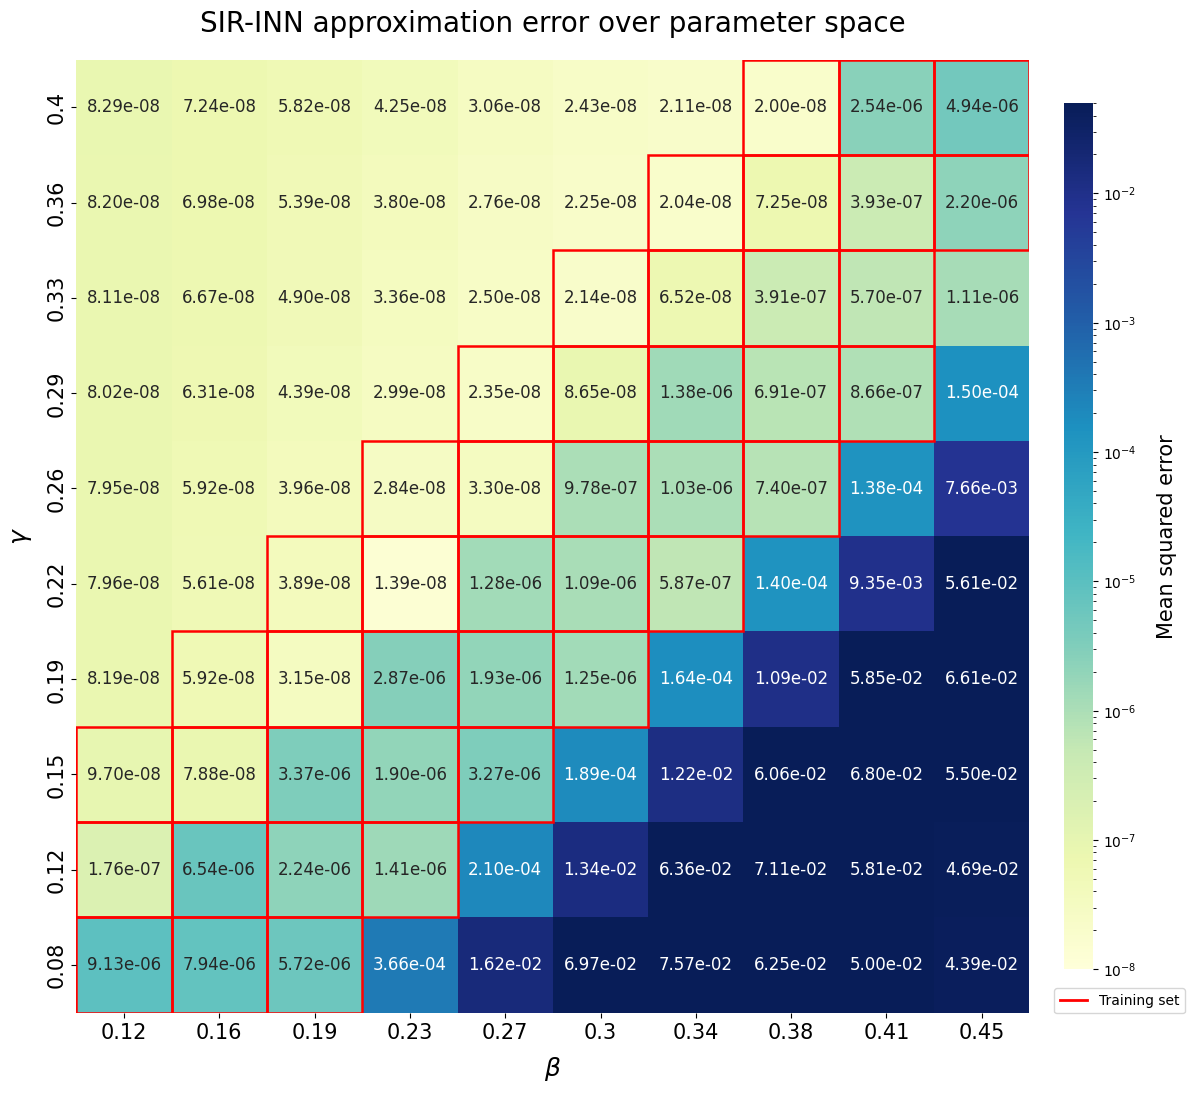

In [21]:
fig3 = sirinn_error_heatmap(
    error_grid = error_grid, 
    betas_train = betas_train, 
    beta_vals = beta_vals, 
    gammas_train = gammas_train, 
    gamma_vals = gamma_vals
    #vmin=1e-8,
    #vmax=0.05
)

fig3.savefig(f'../tmp_results/Plot/approximation/sirinn_error_heatmap_test.png', bbox_inches='tight', dpi=300)

These analysis support the use of the pretrained SIR-INN as an accurate surrogate of a disease spreading dynamics and a prior for the Bayesian inference and forecasting procedures presented in the following notebooks (`02_parameters_inference.ipynb`, `03_forecast.ipynb`).